In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle
from pathlib import Path

In [ ]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

Saving cfsrALL.csv to cfsrALL.csv


Skipping 2020: no rows after speaker-question filter.


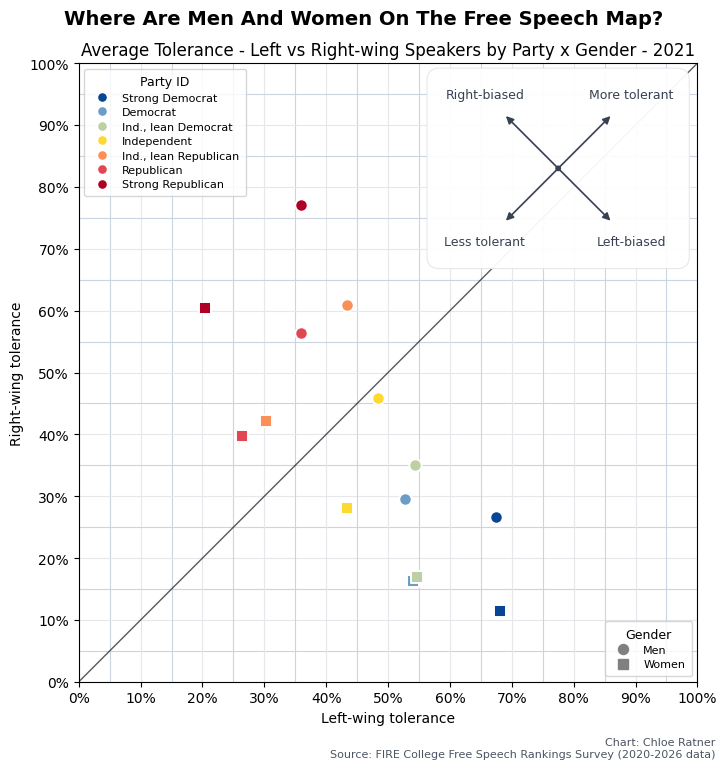

Figure saved to: /content/scatter_left_vs_right_avg_by_party_gender_2021.png


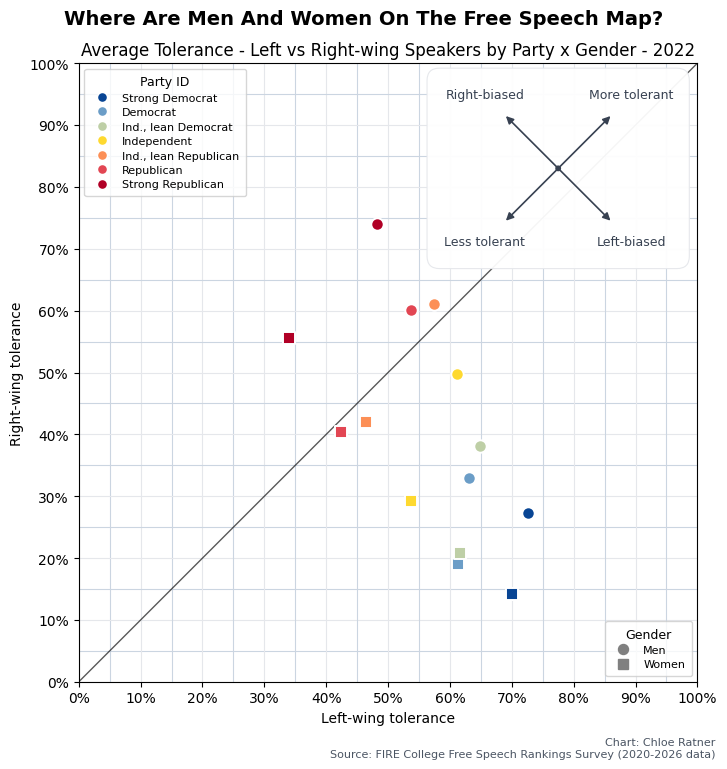

Figure saved to: /content/scatter_left_vs_right_avg_by_party_gender_2022.png


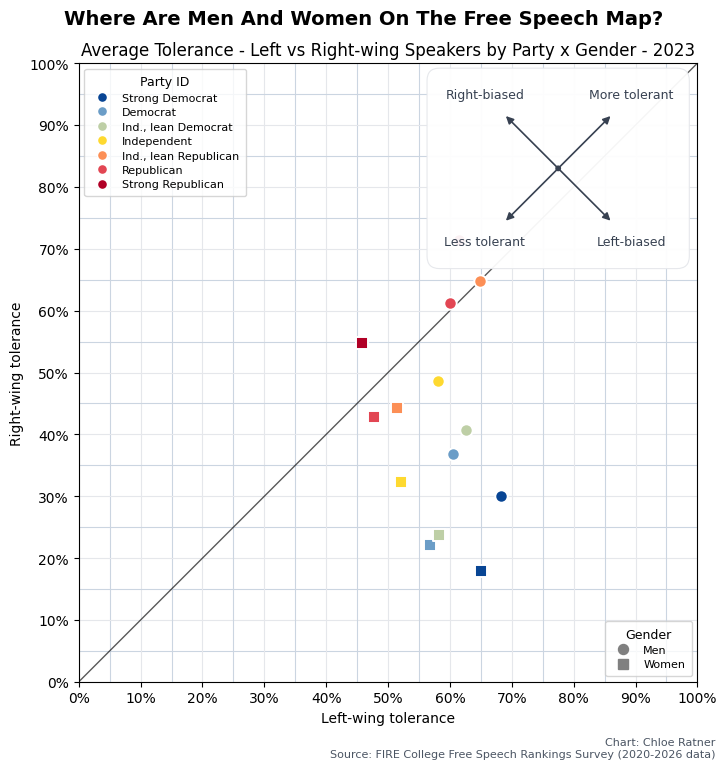

Figure saved to: /content/scatter_left_vs_right_avg_by_party_gender_2023.png


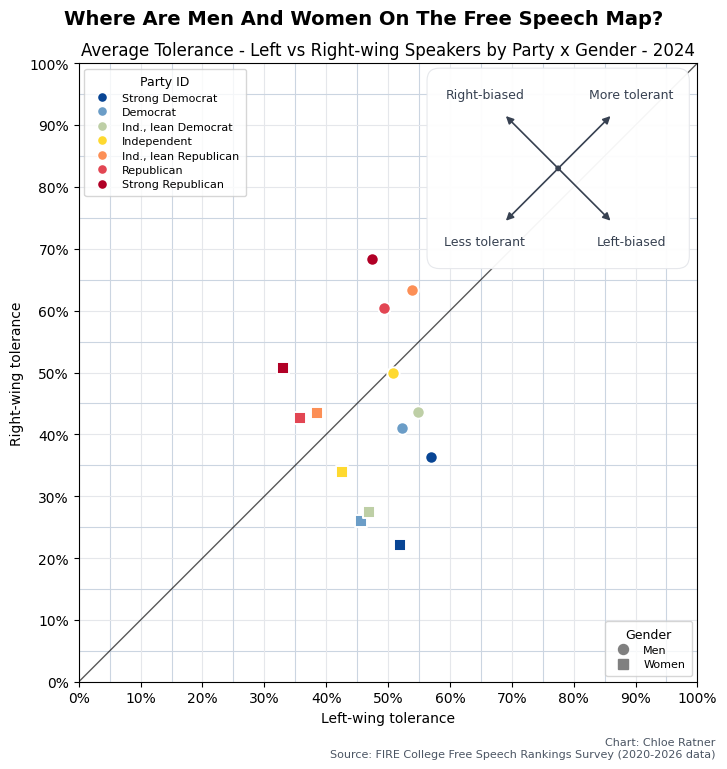

Figure saved to: /content/scatter_left_vs_right_avg_by_party_gender_2024.png


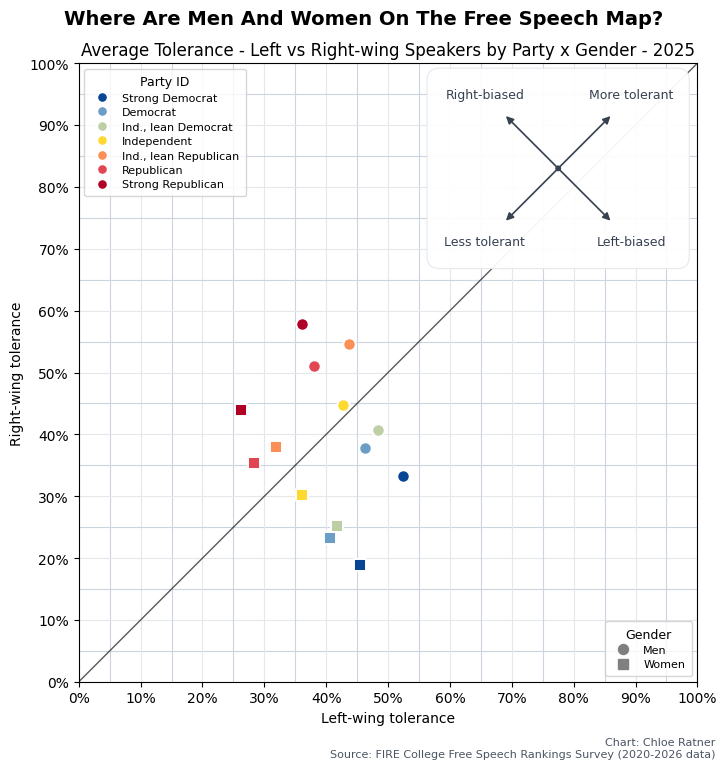

Figure saved to: /content/scatter_left_vs_right_avg_by_party_gender_2025.png
Skipping 2026: no rows after year/gender/party filter.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle
from pathlib import Path

CSV_PATH = Path("cfsrALL.csv")
YEARS = range(2020, 2027)

QUESTION_SETS = {
    2020: {
        "right": ["spk_abortion", "spk_trans", "spk_blm", "spk_israel", "spk_raceint", "spk_newscen"],
        "left": ["spk_whites", "spk_chrstneg", "spk_religlib"],
    },
    2021: {
        "right": ["spk_abortion", "spk_trans", "spk_blm", "spk_lockdown"],
        "left": ["spk_whites", "spk_loot","spk_abolishpolice", "spk_religlib"],
    },
    2022: {
        "right": ["spk_abortion", "spk_trans", "spk_blm", "spk_election"],
        "left": ["spk_whites", "spk_guns", "spk_religlib", "spk_immigration"],
    },
    2023: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_whites", "spk_guns", "spk_religlib"],
    },
    2024: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
    2025: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
    2026: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
}

GENDER_LABELS = {1: "Men", 2: "Women"}

PARTY_LABELS_FULL = {
    1: "Strong Democrat",
    2: "Democrat",
    3: "Ind., lean Democrat",
    4: "Independent",
    5: "Ind., lean Republican",
    6: "Republican",
    7: "Strong Republican",
}

BASE_COMPASS_W = 0.30
BASE_COMPASS_H = 0.30
BASE_COMPASS_SHIFT = 0.055
H_EXPAND_PP = 0.10

COMPASS_W = BASE_COMPASS_W + H_EXPAND_PP
COMPASS_H = BASE_COMPASS_H
COMPASS_SHIFT = BASE_COMPASS_SHIFT - (COMPASS_W - BASE_COMPASS_W) / 2.0

def scale_triad_to_pct(sum_vals, k=3):
    """Maps triad sum from k..4k to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def build_partyid_like_code2(df: pd.DataFrame) -> pd.Series:
    fire = pd.to_numeric(df.get("fire_partyid"), errors="coerce")
    cp = pd.to_numeric(df.get("cp_partyid"), errors="coerce")

    valid_fire_1_7 = (fire >= 1) & (fire <= 7)
    valid_cp_1_7 = (cp >= 1) & (cp <= 7)

    partyid = np.where(
        valid_fire_1_7,
        fire,
        np.where(valid_cp_1_7, cp, np.nan),
    )
    partyid = np.where(pd.isna(partyid) & ((fire == 8) | (cp == 8)), 8, partyid)
    return pd.Series(partyid, index=df.index).astype("Int64")


def add_diagonal_compass(ax, *, width, height, pad=0.02, shift_left):
    cx = 1 - pad - width / 2 - shift_left
    cy = 1 - pad - height / 2

    box = FancyBboxPatch(
        (cx - width / 2, cy - height / 2),
        width,
        height,
        transform=ax.transAxes,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=0.8,
        facecolor="white",
        edgecolor="#e5e7eb",
        alpha=0.95,
        zorder=5,
    )
    ax.add_patch(box)

    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.05

    def r_max(theta):
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        ct = max(ct, 1e-9)
        st = max(st, 1e-9)
        return min((hx - m) / ct, (hy - m) / st)

    directions = [
        (45, "More tolerant"),
        (-45, "Left-biased"),
        (135, "Right-biased"),
        (225, "Less tolerant"),
    ]
    for angle_deg, label in directions:
        th = np.deg2rad(angle_deg)
        rmax = r_max(th)
        r_arrow = rmax * 0.65
        r_label = rmax * 0.88

        ax.add_patch(
            FancyArrowPatch(
                (cx, cy),
                (cx + r_arrow * np.cos(th), cy + r_arrow * np.sin(th)),
                transform=ax.transAxes,
                arrowstyle="-|>",
                mutation_scale=11,
                linewidth=1.2,
                color="#374151",
                zorder=6,
            )
        )
        ax.text(
            cx + r_label * np.cos(th),
            cy + r_label * np.sin(th),
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=9,
            color="#374151",
            zorder=7,
        )

    ax.add_patch(
        Circle(
            (cx, cy),
            radius=min(width, height) * 0.012,
            transform=ax.transAxes,
            color="#374151",
            zorder=7,
        )
    )


def make_party_gender_scatter(df: pd.DataFrame, year: int, right_triad, left_triad):
    df = df.copy()

    df["right_sum"] = df[right_triad].sum(axis=1).astype(int)
    df["left_sum"] = df[left_triad].sum(axis=1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(right_triad))
    df["left_pct"] = scale_triad_to_pct(df["left_sum"], k=len(left_triad))

    stats = (
        df.groupby(["partyid", "gender_bin"], dropna=True)
        .agg(
            left_avg=("left_pct", "mean"),
            right_avg=("right_pct", "mean"),
            n=("left_pct", "size"),
        )
        .reset_index()
    )

    if stats.empty:
        print(f"Skipping {year}: no groups to plot after filtering.")
        return

    fig, ax = plt.subplots(figsize=(8.8, 8.6))

    cmap_cont = LinearSegmentedColormap.from_list(
        "red_lightred_yellow_lightblue_blue",
        ["#b10026", "#fb6a6a", "#ffd92f", "#9ecae1", "#084594"],
    )
    steps = np.linspace(0, 1, 7)
    party_colors = {pid: cmap_cont(steps[7 - pid]) for pid in range(1, 8)}
    gender_markers = {1: "o", 2: "s"}

    light_gray, medium_gray = "#e5e7eb", "#cbd5e1"
    for v in range(0, 101, 5):
        color = light_gray if (v // 5) % 2 == 0 else medium_gray
        ax.axhline(v, color=color, linewidth=0.8, zorder=0)
        ax.axvline(v, color=color, linewidth=0.8, zorder=0)

    for _, row in stats.iterrows():
        pid = int(row["partyid"])
        gender = int(row["gender_bin"])
        ax.scatter(
            row["left_avg"],
            row["right_avg"],
            s=80,
            c=[party_colors.get(pid)],
            marker=gender_markers.get(gender, "o"),
            edgecolor="white",
            linewidth=1.4,
            zorder=3,
        )

    ax.set_title(
        f"Average Tolerance - Left vs Right-wing Speakers by Party x Gender - {year}"
    )
    ax.set_xlabel("Left-wing tolerance")
    ax.set_ylabel("Right-wing tolerance")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks(range(0, 101, 10))
    ax.set_yticks(range(0, 101, 10))
    ax.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.65, zorder=1.5)

    party_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=party_colors[pid],
            markeredgecolor="white",
            markersize=8,
            label=PARTY_LABELS_FULL[pid],
        )
        for pid in range(1, 8)
    ]
    gender_handles = [
        Line2D([0], [0], marker="o", linestyle="", color="gray", label="Men", markersize=8),
        Line2D([0], [0], marker="s", linestyle="", color="gray", label="Women", markersize=8),
    ]

    leg1 = ax.legend(
        handles=party_handles,
        title="Party ID",
        loc="upper left",
        frameon=True,
        fontsize=8,
        title_fontsize=9,
        markerscale=0.9,
        borderpad=0.6,
        labelspacing=0.4,
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=gender_handles,
        title="Gender",
        loc="lower right",
        frameon=True,
        fontsize=8,
        title_fontsize=9,
        markerscale=0.9,
        borderpad=0.6,
        labelspacing=0.4,
    )

    add_diagonal_compass(
        ax,
        width=COMPASS_W,
        height=COMPASS_H,
        pad=0.02,
        shift_left=COMPASS_SHIFT,
    )

    fig.suptitle(
        "Where Are Men And Women On The Free Speech Map?",
        fontsize=14,
        fontweight="bold",
        y=0.9,
    )
    fig.text(
        0.9,
        0.028,
        f"Chart: Chloe Ratner\nSource: FIRE College Free Speech Rankings Survey ({min(YEARS)}-{max(YEARS)} data)",
        ha="right",
        va="bottom",
        fontsize=8,
        color="#4b5563",
    )

    fig.tight_layout(rect=[0.02, 0.05, 0.98, 0.92])

    out_path = Path(f"scatter_left_vs_right_avg_by_party_gender_{year}.png")
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")


def main():
    df = pd.read_csv(CSV_PATH, low_memory=False)

    all_question_cols = sorted({
        col
        for qs in QUESTION_SETS.values()
        for col in qs["right"] + qs["left"]
    })

    numeric_cols = [
        "datayear",
        "gender_bin",
        "fire_partyid",
        "cp_partyid",
        *all_question_cols,
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["partyid"] = build_partyid_like_code2(df)

    for year in YEARS:
        right_triad = QUESTION_SETS[year]["right"]
        left_triad = QUESTION_SETS[year]["left"]
        spk_all = right_triad + left_triad

        missing = [col for col in spk_all if col not in df.columns]
        if missing:
            print(f"Skipping {year}: missing columns {missing}")
            continue

        d = df[
            (df["datayear"] == year)
            & (df["gender_bin"].isin([1, 2]))
            & (df["partyid"].isin(range(1, 8)))
        ].copy()

        if d.empty:
            print(f"Skipping {year}: no rows after year/gender/party filter.")
            continue

        in_range = d[spk_all].ge(1) & d[spk_all].le(4)
        d = d[in_range.all(axis=1)].copy()

        if d.empty:
            print(f"Skipping {year}: no rows after speaker-question filter.")
            continue

        make_party_gender_scatter(d, year, right_triad, left_triad)


if __name__ == "__main__":
    main()

Skipping 2020: no rows after speaker-question filter.
Skipping 2026: no rows after year/gender/party filter.


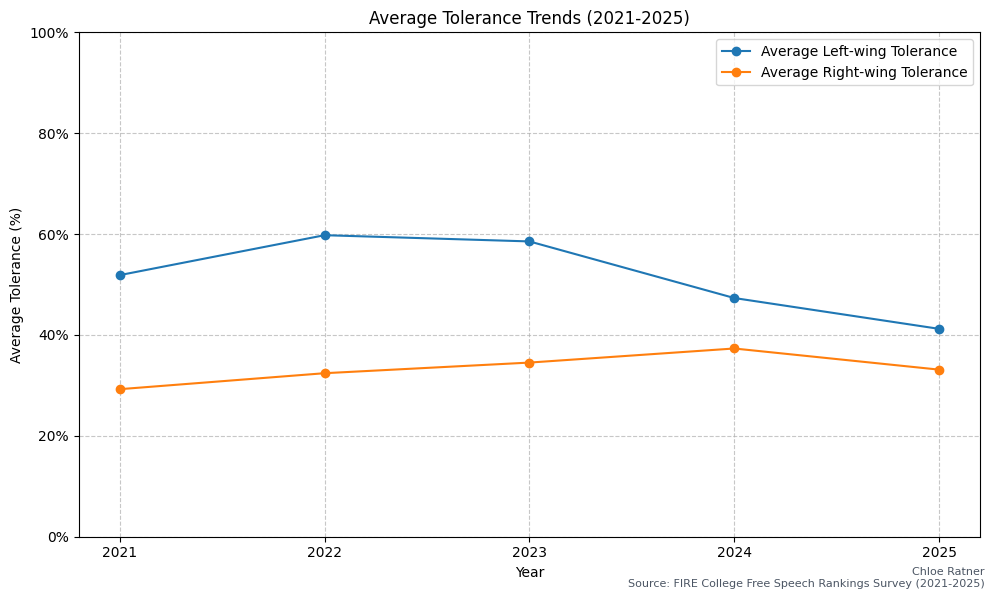

In [ ]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df["partyid"] = build_partyid_like_code2(df)

yearly_tolerance_data = []

for year in YEARS:
    right_triad = QUESTION_SETS[year]["right"]
    left_triad = QUESTION_SETS[year]["left"]
    spk_all = right_triad + left_triad

    missing = [col for col in spk_all if col not in df.columns]
    if missing:
        print(f"Skipping {year}: missing columns {missing}")
        continue

    d = df[
        (df["datayear"] == year)
        & (df["gender_bin"].isin([1, 2]))
        & (df["partyid"].isin(range(1, 8)))
    ].copy()

    if d.empty:
        print(f"Skipping {year}: no rows after year/gender/party filter.")
        continue

    in_range = d[spk_all].ge(1) & d[spk_all].le(4)
    d = d[in_range.all(axis=1)].copy()

    if d.empty:
        print(f"Skipping {year}: no rows after speaker-question filter.")
        continue

    d["right_sum"] = d[right_triad].sum(axis=1).astype(int)
    d["left_sum"] = d[left_triad].sum(axis=1).astype(int)
    d["right_pct"] = scale_triad_to_pct(d["right_sum"], k=len(right_triad))
    d["left_pct"] = scale_triad_to_pct(d["left_sum"], k=len(left_triad))

    avg_left = d["left_pct"].mean()
    avg_right = d["right_pct"].mean()
    yearly_tolerance_data.append({"year": year, "avg_left_tolerance": avg_left, "avg_right_tolerance": avg_right})

tolerance_trends = pd.DataFrame(yearly_tolerance_data)

plt.figure(figsize=(10, 6))
plt.plot(tolerance_trends["year"], tolerance_trends["avg_left_tolerance"], marker='o', label='Average Left-wing Tolerance')
plt.plot(tolerance_trends["year"], tolerance_trends["avg_right_tolerance"], marker='o', label='Average Right-wing Tolerance')
plt.title(f'Average Tolerance Trends (2021-2025)')
plt.xlabel('Year')
plt.ylabel('Average Tolerance (%)')
plt.xticks(tolerance_trends["year"])
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.figtext(0.99, 0.01, "Chloe Ratner\nSource: FIRE College Free Speech Rankings Survey (2021-2025)", ha='right', va='bottom', fontsize=8, color='#4b5563')
plt.tight_layout()
plt.show()

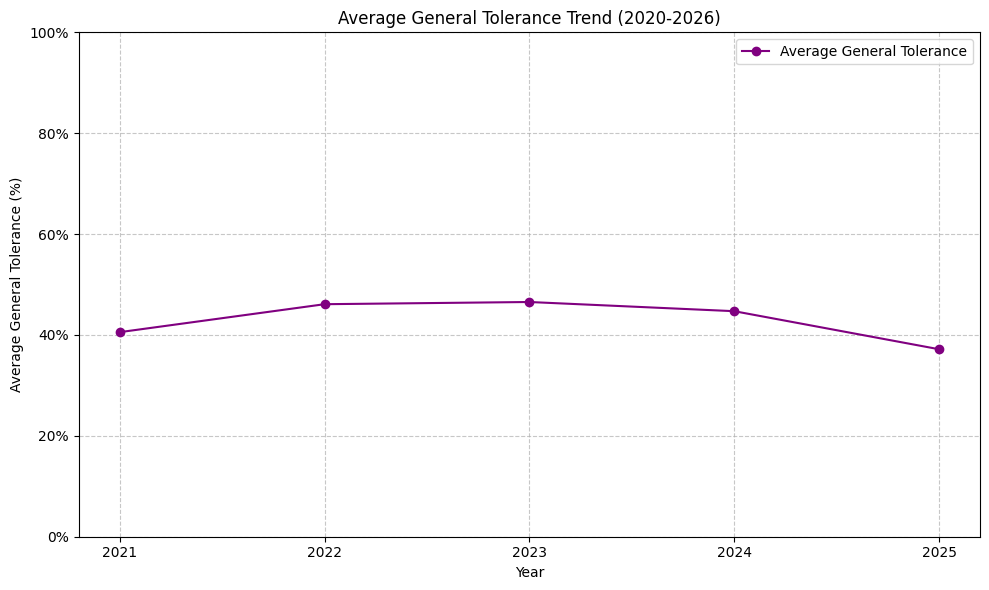

In [ ]:
import matplotlib.pyplot as plt

# Calculate a general tolerance metric by averaging left and right tolerance
tolerance_trends['avg_general_tolerance'] = (tolerance_trends['avg_left_tolerance'] + tolerance_trends['avg_right_tolerance']) / 2

plt.figure(figsize=(10, 6))
plt.plot(tolerance_trends['year'], tolerance_trends['avg_general_tolerance'], marker='o', linestyle='-', color='purple', label='Average General Tolerance')
plt.title(f'Average General Tolerance Trend ({min(YEARS)}-{max(YEARS)})')
plt.xlabel('Year')
plt.ylabel('Average General Tolerance (%)')
plt.xticks(tolerance_trends['year'])
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Ensure df and other necessary variables are available (re-loading and preprocessing as in main function)
# This assumes CSV_PATH, QUESTION_SETS, scale_triad_to_pct, build_partyid_like_code2 are defined in the environment.

df = pd.read_csv(CSV_PATH, low_memory=False)

all_question_cols = sorted({
    col
    for qs in QUESTION_SETS.values()
    for col in qs["right"] + qs["left"]
})

numeric_cols = [
    "datayear",
    "gender_bin",
    "fire_partyid",
    "cp_partyid",
    *all_question_cols,
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["partyid"] = build_partyid_like_code2(df)

def get_common_questions(year1, year2, question_sets):
    """Returns the common 'right' and 'left' speaker questions between two years."""
    qs1_right = set(question_sets[year1]["right"])
    qs1_left = set(question_sets[year1]["left"])
    qs2_right = set(question_sets[year2]["right"])
    qs2_left = set(question_sets[year2]["left"])

    common_right = list(qs1_right.intersection(qs2_right))
    common_left = list(qs1_left.intersection(qs2_left))
    return common_right, common_left

def calculate_average_tolerance(data_frame, year, right_triad, left_triad):
    """Calculates average left and right tolerance for a given year and question set."""
    d_year = data_frame[
        (data_frame["datayear"] == year)
        & (data_frame["gender_bin"].isin([1, 2]))
        & (data_frame["partyid"].isin(range(1, 8)))
    ].copy()

    spk_all = right_triad + left_triad

    missing = [col for col in spk_all if col not in d_year.columns]
    if missing:
        print(f"Warning: Missing columns {missing} for year {year}. Skipping calculation.")
        return None, None

    in_range = d_year[spk_all].ge(1) & d_year[spk_all].le(4)
    d_year = d_year[in_range.all(axis=1)].copy()

    if d_year.empty:
        print(f"No data for year {year} after filtering by gender, party, and speaker questions. Skipping calculation.")
        return None, None

    d_year["right_sum"] = d_year[right_triad].sum(axis=1).astype(int)
    d_year["left_sum"] = d_year[left_triad].sum(axis=1).astype(int)
    d_year["right_pct"] = scale_triad_to_pct(d_year["right_sum"], k=len(right_triad))
    d_year["left_pct"] = scale_triad_to_pct(d_year["left_sum"], k=len(left_triad))

    avg_left = d_year["left_pct"].mean()
    avg_right = d_year["right_pct"].mean()
    return avg_left, avg_right

# --- Comparison 2022 vs 2023 ---
print("Calculating tolerance changes between 2022 and 2023...")
year_22 = 2022
year_23 = 2023
common_right_22_23, common_left_22_23 = get_common_questions(year_22, year_23, QUESTION_SETS)

print(f"  Common Right-wing speakers for {year_22}-{year_23}: {common_right_22_23}")
print(f"  Common Left-wing speakers for {year_22}-{year_23}: {common_left_22_23}")

avg_left_22, avg_right_22 = calculate_average_tolerance(df, year_22, common_right_22_23, common_left_22_23)
avg_left_23, avg_right_23 = calculate_average_tolerance(df, year_23, common_right_22_23, common_left_22_23)

if avg_left_22 is not None and avg_left_23 is not None:
    diff_left_22_23 = avg_left_23 - avg_left_22
    diff_right_22_23 = avg_right_23 - avg_right_22
    print(f"\nTolerance Change between {year_22} and {year_23} (using common questions):")
    print(f"  Left-wing Tolerance Change: {diff_left_22_23:.2f} percentage points")
    print(f"  Right-wing Tolerance Change: {diff_right_22_23:.2f} percentage points")
else:
    print(f"\nCould not calculate tolerance change for {year_22}-{year_23} due to insufficient data or missing questions.")

# --- Comparison 2024 vs 2025 ---
print("\nCalculating tolerance changes between 2024 and 2025...")
year_24 = 2024
year_25 = 2025
common_right_24_25, common_left_24_25 = get_common_questions(year_24, year_25, QUESTION_SETS)

print(f"  Common Right-wing speakers for {year_24}-{year_25}: {common_right_24_25}")
print(f"  Common Left-wing speakers for {year_24}-{year_25}: {common_left_24_25}")

avg_left_24, avg_right_24 = calculate_average_tolerance(df, year_24, common_right_24_25, common_left_24_25)
avg_left_25, avg_right_25 = calculate_average_tolerance(df, year_25, common_right_24_25, common_left_24_25)

if avg_left_24 is not None and avg_left_25 is not None:
    diff_left_24_25 = avg_left_25 - avg_left_24
    diff_right_24_25 = avg_right_25 - avg_right_24
    print(f"\nTolerance Change between {year_24} and {year_25} (using common questions):")
    print(f"  Left-wing Tolerance Change: {diff_left_24_25:.2f} percentage points")
    print(f"  Right-wing Tolerance Change: {diff_right_24_25:.2f} percentage points")
else:
    print(f"\nCould not calculate tolerance change for {year_24}-{year_25} due to insufficient data or missing questions.")

Calculating tolerance changes between 2022 and 2023...
  Common Right-wing speakers for 2022-2023: ['spk_abortion', 'spk_blm', 'spk_trans']
  Common Left-wing speakers for 2022-2023: ['spk_religlib', 'spk_whites', 'spk_guns']

Tolerance Change between 2022 and 2023 (using common questions):
  Left-wing Tolerance Change: 1.16 percentage points
  Right-wing Tolerance Change: 2.60 percentage points

Calculating tolerance changes between 2024 and 2025...
  Common Right-wing speakers for 2024-2025: ['spk_abortion', 'spk_blm', 'spk_trans']
  Common Left-wing speakers for 2024-2025: ['spk_kidtrans', 'spk_cathped', 'spk_policekkk']

Tolerance Change between 2024 and 2025 (using common questions):
  Left-wing Tolerance Change: -6.11 percentage points
  Right-wing Tolerance Change: -4.19 percentage points


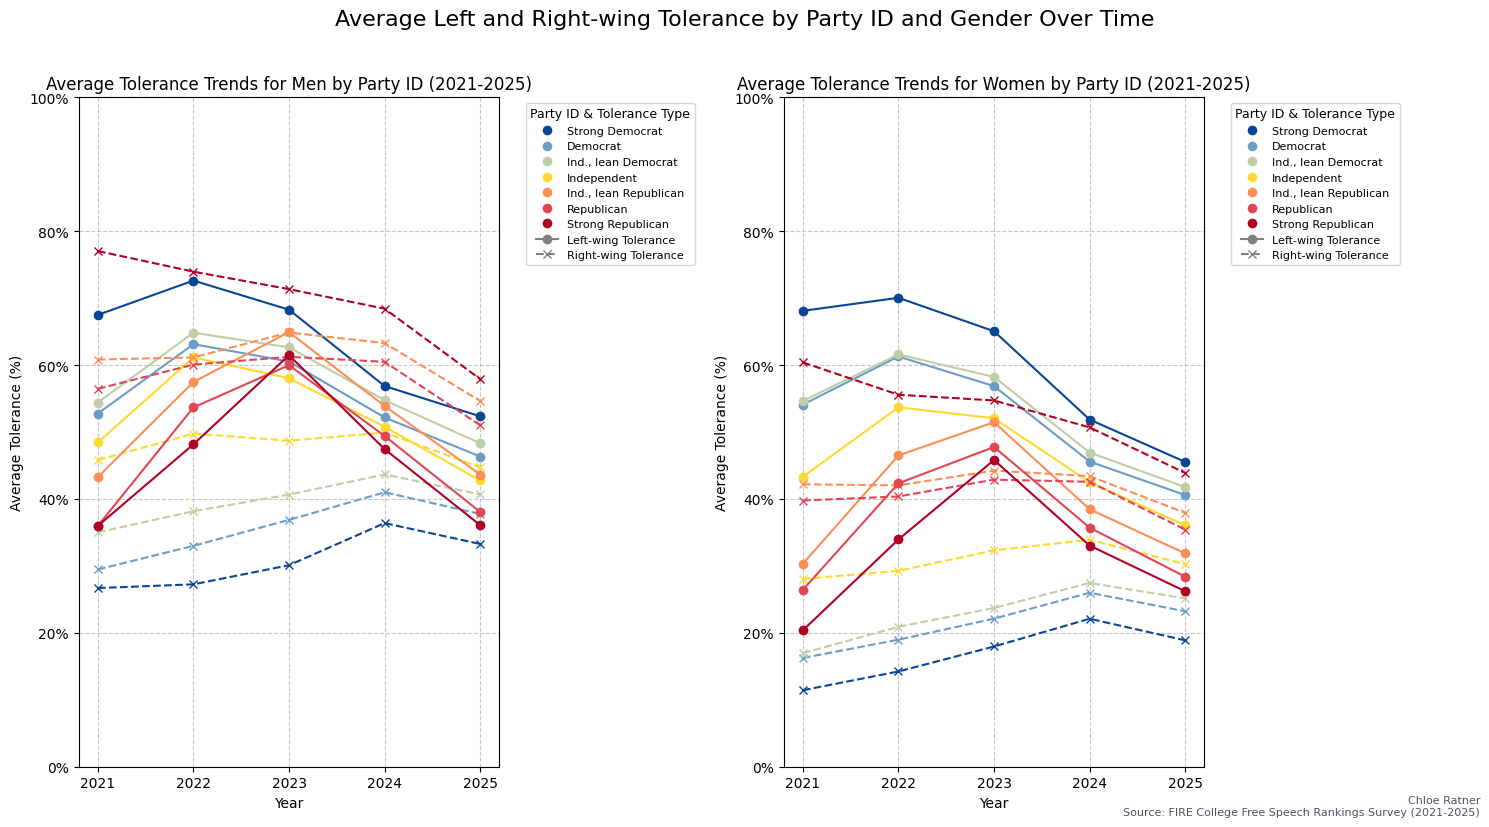

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# --- Data Preparation ---
df_processed = pd.read_csv(CSV_PATH, low_memory=False)
df_processed["partyid"] = build_partyid_like_code2(df_processed)

# Ensure all question columns are numeric
all_question_cols = sorted({
    col
    for qs in QUESTION_SETS.values()
    for col in qs["right"] + qs["left"]
})
numeric_cols_to_convert = [
    "datayear",
    "gender_bin",
    *all_question_cols,
]
for col in numeric_cols_to_convert:
    if col in df_processed.columns:
        df_processed[col] = pd.to_numeric(df_processed[col], errors="coerce")

gender_party_tolerance_data = []

# Using YEARS defined in the notebook context
years_to_process = sorted(list(YEARS))

for year in years_to_process:
    if year not in QUESTION_SETS:
        continue

    right_triad = QUESTION_SETS[year]["right"]
    left_triad = QUESTION_SETS[year]["left"]
    spk_all = right_triad + left_triad

    missing = [col for col in spk_all if col not in df_processed.columns]
    if missing:
        continue

    d_year = df_processed[
        (df_processed["datayear"] == year)
        & (df_processed["gender_bin"].isin([1, 2]))  # Filter for Men (1) and Women (2)
        & (df_processed["partyid"].isin(range(1, 8)))  # Filter for valid party IDs
    ].copy()

    if d_year.empty:
        continue

    in_range = d_year[spk_all].ge(1) & d_year[spk_all].le(4)
    d_year = d_year[in_range.all(axis=1)].copy()

    if d_year.empty:
        continue

    d_year["right_sum"] = d_year[right_triad].sum(axis=1).astype(int)
    d_year["left_sum"] = d_year[left_triad].sum(axis=1).astype(int)
    d_year["right_pct"] = scale_triad_to_pct(d_year["right_sum"], k=len(right_triad))
    d_year["left_pct"] = scale_triad_to_pct(d_year["left_sum"], k=len(left_triad))

    # Add the 'year' column to d_year for grouping
    d_year['year'] = year

    # Group by year, partyid and gender_bin
    yearly_gender_party_avg = d_year.groupby(['year', 'partyid', 'gender_bin']).agg(
        avg_left_tolerance=('left_pct', 'mean'),
        avg_right_tolerance=('right_pct', 'mean')
    ).reset_index()

    gender_party_tolerance_data.append(yearly_gender_party_avg)

# Concatenate all yearly data
gender_party_tolerance_df = pd.concat(gender_party_tolerance_data, ignore_index=True)

# Add descriptive labels
gender_party_tolerance_df['gender_label'] = gender_party_tolerance_df['gender_bin'].map(GENDER_LABELS)
gender_party_tolerance_df['party_label'] = gender_party_tolerance_df['partyid'].map(PARTY_LABELS_FULL)

# Get actual min and max years from the processed data for titles
actual_min_year = gender_party_tolerance_df['year'].min()
actual_max_year = gender_party_tolerance_df['year'].max()

# --- Plotting ---
plt.figure(figsize=(15, 8))

# Define colors for parties
cmap_cont = LinearSegmentedColormap.from_list(
    "red_lightred_yellow_lightblue_blue",
    ["#b10026", "#fb6a6a", "#ffd92f", "#9ecae1", "#084594"],
)
steps = np.linspace(0, 1, 7)
party_colors = {pid: cmap_cont(steps[7 - pid]) for pid in range(1, 8)}

# Plot for Men
ax1 = plt.subplot(1, 2, 1)
for party_id in sorted(gender_party_tolerance_df['partyid'].unique()):
    men_data = gender_party_tolerance_df[(gender_party_tolerance_df['gender_bin'] == 1) & (gender_party_tolerance_df['partyid'] == party_id)]
    if not men_data.empty:
        ax1.plot(men_data['year'], men_data['avg_left_tolerance'], marker='o', linestyle='-', color=party_colors.get(party_id))
        ax1.plot(men_data['year'], men_data['avg_right_tolerance'], marker='x', linestyle='--', color=party_colors.get(party_id))

ax1.set_title(f'Average Tolerance Trends for Men by Party ID ({actual_min_year}-{actual_max_year})')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Tolerance (%)')
ax1.set_xticks(sorted(gender_party_tolerance_df['year'].unique()))
ax1.set_ylim(0, 100)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.yaxis.set_major_formatter(PercentFormatter(xmax=100))

# Create custom legend for men's plot (Party ID and Tolerance Type)
party_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=party_colors[pid],
        markeredgecolor='white',
        markersize=8,
        label=PARTY_LABELS_FULL[pid],
    ) for pid in sorted(gender_party_tolerance_df['partyid'].unique())
]
tolerance_type_handles = [
    Line2D([0], [0], color='gray', linestyle='-', marker='o', label='Left-wing Tolerance'),
    Line2D([0], [0], color='gray', linestyle='--', marker='x', label='Right-wing Tolerance')
]
ax1.legend(handles=party_handles + tolerance_type_handles, title="Party ID & Tolerance Type", loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8, title_fontsize=9)


# Plot for Women
ax2 = plt.subplot(1, 2, 2)
for party_id in sorted(gender_party_tolerance_df['partyid'].unique()):
    women_data = gender_party_tolerance_df[(gender_party_tolerance_df['gender_bin'] == 2) & (gender_party_tolerance_df['partyid'] == party_id)]
    if not women_data.empty:
        ax2.plot(women_data['year'], women_data['avg_left_tolerance'], marker='o', linestyle='-', color=party_colors.get(party_id))
        ax2.plot(women_data['year'], women_data['avg_right_tolerance'], marker='x', linestyle='--', color=party_colors.get(party_id))

ax2.set_title(f'Average Tolerance Trends for Women by Party ID ({actual_min_year}-{actual_max_year})')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Tolerance (%)')
ax2.set_xticks(sorted(gender_party_tolerance_df['year'].unique()))
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax2.legend(handles=party_handles + tolerance_type_handles, title="Party ID & Tolerance Type", loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8, title_fontsize=9)


plt.suptitle('Average Left and Right-wing Tolerance by Party ID and Gender Over Time', fontsize=16, y=1.02)
plt.figtext(
        0.99,
        0.01,
        "Chloe Ratner\nSource: FIRE College Free Speech Rankings Survey (2021-2025)",
        ha="right",
        va="bottom",
        fontsize=8,
        color="#4b5563",
    )
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

In [ ]:
import pandas as pd

# Create a combined DataFrame with calculated tolerance percentages for all relevant years
combined_tolerance_df_list = []

for year in YEARS:
    if year not in QUESTION_SETS:
        continue

    right_triad = QUESTION_SETS[year]["right"]
    left_triad = QUESTION_SETS[year]["left"]
    spk_all = right_triad + left_triad

    # Filter data for the current year, gender, and party ID
    d_year_filtered = df[
        (df["datayear"] == year)
        & (df["gender_bin"].isin([1, 2]))
        & (df["partyid"].isin(range(1, 8)))
    ].copy()

    # Check for missing columns (should be handled by outer loop of main already, but good practice)
    missing_cols_for_year = [col for col in spk_all if col not in d_year_filtered.columns]
    if missing_cols_for_year:
        print(f"Skipping year {year} due to missing speaker question columns: {missing_cols_for_year}")
        continue

    # Filter out rows with values outside the 1-4 range for speaker questions
    in_range = d_year_filtered[spk_all].ge(1) & d_year_filtered[spk_all].le(4)
    d_year_filtered = d_year_filtered[in_range.all(axis=1)].copy()

    if d_year_filtered.empty:
        print(f"Skipping year {year}: no valid rows after filtering for speaker questions.")
        continue

    # Calculate sums and percentages
    d_year_filtered["right_sum"] = d_year_filtered[right_triad].sum(axis=1).astype(int)
    d_year_filtered["left_sum"] = d_year_filtered[left_triad].sum(axis=1).astype(int)
    d_year_filtered["right_pct"] = scale_triad_to_pct(d_year_filtered["right_sum"], k=len(right_triad))
    d_year_filtered["left_pct"] = scale_triad_to_pct(d_year_filtered["left_sum"], k=len(left_triad))

    # Select relevant columns for the combined DataFrame and append
    combined_tolerance_df_list.append(d_year_filtered[['datayear', 'partyid', 'gender_bin', 'left_pct', 'right_pct']])

# Concatenate all yearly data into a single DataFrame
combined_df = pd.concat(combined_tolerance_df_list, ignore_index=True)
print(f"Combined DataFrame created with data for years: {sorted(combined_df['datayear'].unique())}")
display(combined_df.head())

Skipping year 2020: no valid rows after filtering for speaker questions.
Skipping year 2026: no valid rows after filtering for speaker questions.
Combined DataFrame created with data for years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,datayear,partyid,gender_bin,left_pct,right_pct
0,2021,1,2,83.333333,0.000000
1,2021,3,2,91.666667,0.000000
2,2021,1,2,33.333333,8.333333
3,2021,5,2,41.666667,33.333333
4,2021,5,1,0.000000,91.666667


In [ ]:
# Downloading Data to PDF:
# Installation Requirements
!apt-get -qq update
!apt-get install -y pandoc texlive-xetex texlive-fonts-recommended texlive-plain-generic

from google.colab import drive, files
# Mount Google Drive
drive.mount('/content/drive')

notebook_name = input(
"Enter your notebook’s exact file name,\n"
)

input_path = f"/content/drive/MyDrive/{notebook_name}"
output_path = input_path.replace(".ipynb", ".pdf")

# Convert to PDF
!jupyter nbconvert --to pdf "{input_path}"

# Download the PDF
files.download(output_path)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 97 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter your notebook’s exact file name,
articlecharts.ipynb
[NbConvertApp] Converting notebook /content/drive/MyDrive/articlecharts.ipynb to pdf
[NbConvertApp] Support files will be in articlecharts_files/
[NbConvertApp] Making directory ./articlecharts_fi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>